<a href="https://colab.research.google.com/github/Du-nara/ME421-Mechanical-Systems-Lab-A3/blob/main/Heat%20Transfer_new/E_20_260_Heat_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ME421 – Mechanical Systems Laboratory
## Dairy Factory Cooling System — Feasibility Analysis
---
**Group:** A3



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Problem Constants (from problem statement) ─────────────────────────────
N   = 40       # Number of containers per day
mm  = 5        # kg  — Mass of milk per container
mc  = 2        # kg  — Mass of empty aluminium container
Cpm = 4000     # J/(kg·K) — Specific heat of milk
Cpc = 921.1    # J/(kg·K) — Specific heat of aluminium (container material)
Tf  = 15       # °C  — Required final storage temperature
t   = 2 * 3600 # s   — Allowed cooling time (2 hours = 7200 s)

print("Problem constants loaded successfully.")
print(f"  Containers per day  : {N}")
print(f"  Milk / container    : {mm} kg    Cp = {Cpm} J/(kg·K)")
print(f"  Container (Al)      : {mc} kg    Cp = {Cpc} J/(kg·K)")
print(f"  Target temperature  : {Tf} °C")
print(f"  Cooling window      : {t/3600:.0f} hr  =  {t} s")


Problem constants loaded successfully.
  Containers per day  : 40
  Milk / container    : 5 kg    Cp = 4000 J/(kg·K)
  Container (Al)      : 2 kg    Cp = 921.1 J/(kg·K)
  Target temperature  : 15 °C
  Cooling window      : 2 hr  =  7200 s


## Part 1 — Proposed Method to Assess Feasibility of the Available AC Unit

### Objective
Determine whether the Air-Conditioning unit available in the Heat Engine Laboratory
has sufficient cooling capacity to cool 40 milk containers from an initial
temperature of 35–40 °C down to 15 °C within a 2-hour window.

---

### Proposed Method

**Step 1 — Calculate the Required Cooling Load (Theoretical)**

Using the **First Law of Thermodynamics**, the total sensible heat that must be
removed from the system (milk + aluminium containers) is:

$$Q_{required} = N \cdot \left[\, m_{milk} \cdot C_{p,milk} + m_{cont} \cdot C_{p,cont} \,\right] \cdot (T_i - T_f)$$

The **minimum average cooling power** the unit must deliver over the 2-hour window:

$$P_{required} = \frac{Q_{required}}{t_{cooling}}$$

Since the initial milk temperature lies in the range 35–40 °C, calculations are
performed for three cases and the **worst case (Ti = 40 °C) is used as the design basis**.

---

**Step 2 — Measure Actual AC Cooling Capacity (Experimental — Part 2)**

The actual cooling capacity of the unit is determined from **air-side psychrometric
measurements** at the evaporator inlet and outlet:

1. Measure dry-bulb (T_db) and wet-bulb (T_wb) temperatures at the evaporator **inlet** and **outlet**
2. Record the air **mass flow rate** through the duct
3. Compute specific enthalpy at each state using psychrometric relations
4. Calculate actual cooling capacity:

$$\dot{Q}_{actual} = \dot{m}_{air} \cdot (h_{in} - h_{out})$$

---

**Step 3 — Feasibility Decision**

| Condition | Verdict |
|---|---|
| $P_{actual} \geq P_{required}$ | ✅ Unit is **SUITABLE** as-is |
| $P_{actual} < P_{required}$ | ❌ Unit is **NOT SUITABLE** — upgrades needed (Part 3) |


In [ ]:
# ── Required Cooling Load — All Three Cases ────────────────────────────────
initial_temps = [35, 37.5, 40]
case_labels   = ["Best Case  (Ti = 35.0 °C)",
                 "Average    (Ti = 37.5 °C)",
                 "Worst Case (Ti = 40.0 °C)"]
results = []

print("=" * 65)
print("  REQUIRED COOLING LOAD CALCULATIONS")
print("=" * 65)

for Ti, lbl in zip(initial_temps, case_labels):
    dT      = Ti - Tf
    Q_milk  = N * mm  * Cpm * dT
    Q_cont  = N * mc  * Cpc * dT
    Q_total = Q_milk + Q_cont
    P_req   = Q_total / t
    results.append({"label": lbl, "Ti": Ti, "dT": dT,
                    "Q_milk": Q_milk, "Q_cont": Q_cont,
                    "Q_total": Q_total, "P_req": P_req})

    print(f"\n  {lbl}")
    print(f"    ΔT                       = {dT:.1f} °C")
    print(f"    Q_milk  = N·mm·Cpm·ΔT   = {Q_milk:>12,.1f} J  ({Q_milk/1e6:.4f} MJ)")
    print(f"    Q_cont  = N·mc·Cpc·ΔT   = {Q_cont:>12,.1f} J  ({Q_cont/1e6:.4f} MJ)")
    print(f"    Q_total = Q_milk+Q_cont  = {Q_total:>12,.1f} J  ({Q_total/1e6:.4f} MJ)")
    print(f"    P_req   = Q_total / t    = {P_req:>12.2f} W  ({P_req/1000:.4f} kW)")

P_design = results[-1]["P_req"]
print(f"\n{'=' * 65}")
print(f"  ► Design Basis (Worst Case)  :  P_required = {P_design/1000:.4f} kW")
print(f"{'=' * 65}")


  REQUIRED COOLING LOAD CALCULATIONS

  Best Case  (Ti = 35.0 °C)
    ΔT                       = 20.0 °C
    Q_milk  = N·mm·Cpm·ΔT   = 16,000,000.0 J  (16.0000 MJ)
    Q_cont  = N·mc·Cpc·ΔT   =  1,473,760.0 J  (1.4738 MJ)
    Q_total = Q_milk+Q_cont  = 17,473,760.0 J  (17.4738 MJ)
    P_req   = Q_total / t    =      2426.91 W  (2.4269 kW)

  Average    (Ti = 37.5 °C)
    ΔT                       = 22.5 °C
    Q_milk  = N·mm·Cpm·ΔT   = 18,000,000.0 J  (18.0000 MJ)
    Q_cont  = N·mc·Cpc·ΔT   =  1,657,980.0 J  (1.6580 MJ)
    Q_total = Q_milk+Q_cont  = 19,657,980.0 J  (19.6580 MJ)
    P_req   = Q_total / t    =      2730.28 W  (2.7303 kW)

  Worst Case (Ti = 40.0 °C)
    ΔT                       = 25.0 °C
    Q_milk  = N·mm·Cpm·ΔT   = 20,000,000.0 J  (20.0000 MJ)
    Q_cont  = N·mc·Cpc·ΔT   =  1,842,200.0 J  (1.8422 MJ)
    Q_total = Q_milk+Q_cont  = 21,842,200.0 J  (21.8422 MJ)
    P_req   = Q_total / t    =      3033.64 W  (3.0336 kW)

  ► Design Basis (Worst Case)  :  P_required = 3.0

In [ ]:
# ── Summary Table ──────────────────────────────────────────────────────────
df = pd.DataFrame({
    "Initial Temp (°C)" : [r["Ti"]                    for r in results],
    "ΔT (°C)"           : [r["dT"]                    for r in results],
    "Q_milk (MJ)"       : [round(r["Q_milk"]/1e6,  4) for r in results],
    "Q_cont (MJ)"       : [round(r["Q_cont"]/1e6,  4) for r in results],
    "Q_total (MJ)"      : [round(r["Q_total"]/1e6, 4) for r in results],
    "P_required (kW)"   : [round(r["P_req"]/1000,  4) for r in results],
    "Case"              : ["Best", "Average", "Worst ← Design Basis"]
})

print("Results Summary:\n")
print(df.to_string(index=False))


Results Summary:

 Initial Temp (°C)  ΔT (°C)  Q_milk (MJ)  Q_cont (MJ)  Q_total (MJ)  P_required (kW)                 Case
              35.0     20.0         16.0       1.4738       17.4738           2.4269                 Best
              37.5     22.5         18.0       1.6580       19.6580           2.7303              Average
              40.0     25.0         20.0       1.8422       21.8422           3.0336 Worst ← Design Basis


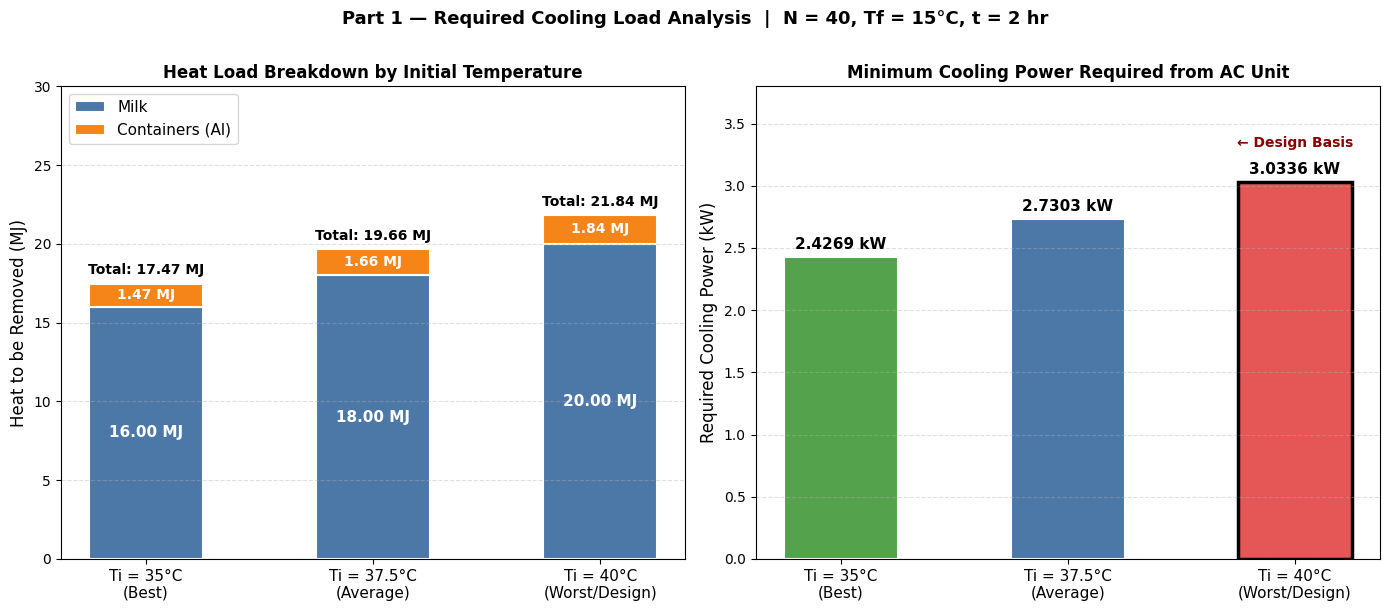

Chart saved: part1_cooling_load.png


In [ ]:
# ── Figure 1: Heat Load Breakdown (Stacked Bar) ────────────────────────────
labels = ["Ti = 35°C\n(Best)", "Ti = 37.5°C\n(Average)", "Ti = 40°C\n(Worst/Design)"]
q_milk = [r["Q_milk"]/1e6  for r in results]
q_cont = [r["Q_cont"]/1e6  for r in results]
powers = [r["P_req"]/1000   for r in results]
x      = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Stacked bar — heat components
ax1 = axes[0]
b1 = ax1.bar(x, q_milk, 0.5, label="Milk", color="#4C78A8", edgecolor="white", lw=1.5)
b2 = ax1.bar(x, q_cont, 0.5, bottom=q_milk, label="Containers (Al)",
             color="#F58518", edgecolor="white", lw=1.5)
for i, (qm, qc) in enumerate(zip(q_milk, q_cont)):
    ax1.text(i, qm / 2,          f"{qm:.2f} MJ", ha="center", va="center",
             color="white", fontsize=11, fontweight="bold")
    ax1.text(i, qm + qc / 2,     f"{qc:.2f} MJ", ha="center", va="center",
             color="white", fontsize=10, fontweight="bold")
    ax1.text(i, qm + qc + 0.4,   f"Total: {qm+qc:.2f} MJ", ha="center",
             va="bottom", fontsize=10, fontweight="bold", color="black")
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel("Heat to be Removed (MJ)", fontsize=12)
ax1.set_title("Heat Load Breakdown by Initial Temperature", fontsize=12, fontweight="bold")
ax1.legend(fontsize=11, loc="upper left")
ax1.set_ylim(0, 30)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Right: Required cooling power
ax2 = axes[1]
bar_colors = ["#54A24B", "#4C78A8", "#E45756"]
bars = ax2.bar(x, powers, 0.5, color=bar_colors, edgecolor="white", lw=1.5)
for bar, val in zip(bars, powers):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.04,
             f"{val:.4f} kW", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylabel("Required Cooling Power (kW)", fontsize=12)
ax2.set_title("Minimum Cooling Power Required from AC Unit", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 3.8)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.grid(axis="y", linestyle="--", alpha=0.4)
bars[2].set_edgecolor("black"); bars[2].set_linewidth(2.5)
ax2.text(2, powers[2] + 0.28, "← Design Basis", ha="center",
         fontsize=10, color="darkred", fontweight="bold")

fig.suptitle("Part 1 — Required Cooling Load Analysis  |  N = 40, Tf = 15°C, t = 2 hr",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("part1_cooling_load.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: part1_cooling_load.png")


## Part 2 — Experimental Determination of AC Unit Cooling Capacity

### Working Principle of the Cooling Unit
The unit in the Heat Engine Laboratory is a **vapour-compression refrigeration system**.
It operates by circulating refrigerant through four stages:

| Component | Process |
|---|---|
| **Compressor** | Refrigerant vapour is compressed → high pressure, high temperature |
| **Condenser** | Hot refrigerant rejects heat to room air → condenses to liquid |
| **Expansion Valve** | Liquid refrigerant expands → pressure and temperature drop sharply |
| **Evaporator** | Cold refrigerant absorbs heat from the supply air → air is cooled |

### How Cooling Capacity is Calculated
The actual cooling capacity is evaluated from the **air side** using psychrometric measurements
at the evaporator **inlet** (Ta) and **outlet** (Tb).

**Step 1 — Saturation vapour pressure at wet bulb temperature (Magnus-Tetens relation):**
$$P_{swb} = 0.61078 \times e^{\left(\frac{17.27 \times T_{wb}}{T_{wb} + 237.3}\right)} \quad \text{[kPa]}$$

**Step 2 — Actual vapour pressure:**
$$P_v = P_{swb} - 0.000662 \times P_{atm} \times (T_{db} - T_{wb}) \quad \text{[kPa]}$$

**Step 3 — Humidity ratio:**
$$\omega = \frac{0.62194 \times P_v}{P_{atm} - P_v} \quad \text{[kg vapour / kg dry air]}$$

**Step 4 — Specific enthalpy of moist air:**
$$h = 1.006 \cdot T_{db} + \omega \cdot (2501 + 1.86 \cdot T_{db}) \quad \text{[kJ/kg dry air]}$$

**Step 5 — Actual cooling capacity:**
$$\dot{Q}_{actual} = \dot{m}_{air} \cdot (h_{in} - h_{out}) \quad \text{[kW]}$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════
# TABLE 1 — Gas Side Temperature Measurements
# ════════════════════════════════════════════════════════════════
time_min    = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
air_flow    = [30]*13                     # kg/hr  (constant)
T3          = [31.3, 31.2, 31.4, 31.0, 31.2, 31.0, 31.3,
               31.4, 31.3, 31.1, 31.1, 31.1, 30.9]  # Room return air (°C)
T1          = [44.6, 44.3, 44.7, 44.4, 44.5, 44.1, 44.3,
               44.4, 44.4, 44.3, 44.1, 44.5, 44.8]  # Condenser inlet (°C)
T2          = [32.7, 32.8, 32.4, 32.3, 32.2, 32.0, 31.9,
               32.1, 31.8, 31.6, 31.5, 31.6, 31.7]  # Condenser outlet (°C)
T4          = [10.2, 10.0, 10.1, 10.2,  9.7,  9.6,  9.5,
                9.1,  9.6,  9.7,  9.0,  9.2,  8.8]  # Evaporator inlet  (°C)
T5          = [11.2, 11.5, 10.5, 11.0, 11.0, 10.8, 11.5,
               10.2, 10.6, 10.6, 10.0, 10.5, 10.6]  # Evaporator outlet (°C)
P_low       = [0.3]*13                    # MPa (constant)
P_high      = [1.8]*13                    # MPa (constant)

# ════════════════════════════════════════════════════════════════
# TABLE 2 — Air Side Psychrometric Measurements
# ════════════════════════════════════════════════════════════════
# Ta = Evaporator inlet air   |   Tb = Evaporator outlet air
Ta_db = [24.1, 23.3, 22.7, 22.4, 22.1, 21.9, 21.8,
         21.6, 21.4, 21.2, 21.1, 21.0, 20.9]   # Inlet  dry bulb  (°C)
Tb_db = [20.6, 20.4, 19.8, 19.3, 18.9, 18.7, 18.4,
         18.2, 18.0, 17.8, 17.7, 17.6, 17.4]   # Outlet dry bulb  (°C)
Ta_wb = [17.2, 17.1, 16.7, 16.6, 16.5, 16.4, 16.2,
         16.1, 15.9, 15.9, 15.7, 15.7, 15.4]   # Inlet  wet bulb  (°C)
Tb_wb = [17.1, 17.1, 16.9, 16.8, 16.6, 16.5, 16.4,
         16.3, 16.2, 16.1, 16.0, 16.0, 15.8]   # Outlet wet bulb  (°C)

# Convert numpy arrays
time_min = np.array(time_min)
Ta_db = np.array(Ta_db);  Tb_db = np.array(Tb_db)
Ta_wb = np.array(Ta_wb);  Tb_wb = np.array(Tb_wb)
T3 = np.array(T3); T4 = np.array(T4); T5 = np.array(T5)

print("✓ Observation data loaded")
print(f"  Time steps  : {len(time_min)} readings  (0 – 12 min)")
print(f"  Air flow    : {air_flow[0]} kg/hr  =  {air_flow[0]/3600:.6f} kg/s  (constant)")


✓ Observation data loaded
  Time steps  : 13 readings  (0 – 12 min)
  Air flow    : 30 kg/hr  =  0.008333 kg/s  (constant)


In [2]:
# ── Psychrometric Constants ─────────────────────────────────────────────────
Patm = 101.325   # kPa — atmospheric pressure

def moist_air_enthalpy(Tdb, Twb, Patm=101.325):
    """
    Calculate specific enthalpy of moist air using psychrometric relations.

    Parameters
    ----------
    Tdb  : dry bulb temperature  (°C)
    Twb  : wet bulb temperature  (°C)
    Patm : atmospheric pressure  (kPa), default 101.325

    Returns
    -------
    h    : specific enthalpy     (kJ / kg dry air)
    w    : humidity ratio        (kg vapour / kg dry air)
    Pv   : vapour pressure       (kPa)
    """
    # Step 1: Saturation vapour pressure at wet bulb (Magnus–Tetens)
    Pswb = 0.61078 * np.exp(17.27 * Twb / (Twb + 237.3))

    # Step 2: Actual vapour pressure
    Pv   = Pswb - 0.000662 * Patm * (Tdb - Twb)

    # Step 3: Humidity ratio
    w    = 0.62194 * Pv / (Patm - Pv)

    # Step 4: Specific enthalpy   [kJ/kg dry air]
    h    = 1.006 * Tdb + w * (2501 + 1.86 * Tdb)

    return h, w, Pv

print("✓ Enthalpy function defined")

# ── Quick Verification at t = 0 ─────────────────────────────────────────────
h_in_0,  w_in_0,  Pv_in_0  = moist_air_enthalpy(Ta_db[0], Ta_wb[0])
h_out_0, w_out_0, Pv_out_0 = moist_air_enthalpy(Tb_db[0], Tb_wb[0])

print(f"\n  Verification at t = 0 min:")
print(f"  Inlet  (Ta_db={Ta_db[0]}, Ta_wb={Ta_wb[0]})")
print(f"    Pv   = {Pv_in_0:.4f} kPa  |  ω = {w_in_0:.6f} kg/kg  |  h = {h_in_0:.4f} kJ/kg")
print(f"  Outlet (Tb_db={Tb_db[0]}, Tb_wb={Tb_wb[0]})")
print(f"    Pv   = {Pv_out_0:.4f} kPa  |  ω = {w_out_0:.6f} kg/kg  |  h = {h_out_0:.4f} kJ/kg")
print(f"  Δh = h_in - h_out = {h_in_0 - h_out_0:.4f} kJ/kg")


✓ Enthalpy function defined

  Verification at t = 0 min:
  Inlet  (Ta_db=24.1, Ta_wb=17.2)
    Pv   = 1.4995 kPa  |  ω = 0.009342 kg/kg  |  h = 48.0289 kJ/kg
  Outlet (Tb_db=20.6, Tb_wb=17.1)
    Pv   = 1.7152 kPa  |  ω = 0.010709 kg/kg  |  h = 47.9181 kJ/kg
  Δh = h_in - h_out = 0.1109 kJ/kg


In [3]:
# ── Air Mass Flow Rate ───────────────────────────────────────────────────────
m_dot = air_flow[0] / 3600   # kg/s  (30 kg/hr → 0.008333 kg/s)

# ── Calculate at Each Time Step ─────────────────────────────────────────────
h_in_arr  = np.zeros(len(time_min))
h_out_arr = np.zeros(len(time_min))
w_in_arr  = np.zeros(len(time_min))
w_out_arr = np.zeros(len(time_min))
Q_dot_arr = np.zeros(len(time_min))
dT_arr    = Ta_db - Tb_db     # dry bulb temperature difference

for i in range(len(time_min)):
    h_in,  w_in,  _ = moist_air_enthalpy(Ta_db[i], Ta_wb[i])
    h_out, w_out, _ = moist_air_enthalpy(Tb_db[i], Tb_wb[i])
    h_in_arr[i]  = h_in
    h_out_arr[i] = h_out
    w_in_arr[i]  = w_in
    w_out_arr[i] = w_out
    Q_dot_arr[i] = m_dot * (h_in - h_out)   # kW

# ── Results Table ────────────────────────────────────────────────────────────
df = pd.DataFrame({
    "Time (min)"    : time_min,
    "Ta_db (°C)"    : Ta_db,
    "Tb_db (°C)"    : Tb_db,
    "ΔT_db (°C)"    : np.round(dT_arr, 2),
    "h_in (kJ/kg)"  : np.round(h_in_arr,  4),
    "h_out (kJ/kg)" : np.round(h_out_arr, 4),
    "Δh (kJ/kg)"    : np.round(h_in_arr - h_out_arr, 4),
    "Q_dot (kW)"    : np.round(Q_dot_arr, 6)
})

print("=" * 80)
print("  PSYCHROMETRIC COOLING CAPACITY — TIME-STEP RESULTS")
print("=" * 80)
print(df.to_string(index=False))

Q_avg = np.mean(Q_dot_arr)
Q_max = np.max(Q_dot_arr)

print(f"\n{'=' * 80}")
print(f"  Average Cooling Capacity   Q_avg = {Q_avg:.6f} kW")
print(f"  Peak    Cooling Capacity   Q_max = {Q_max:.6f} kW")
print(f"  Air mass flow rate         m_dot = {m_dot:.6f} kg/s  ({air_flow[0]} kg/hr)")
print(f"{'=' * 80}")

# ── Feasibility Check ────────────────────────────────────────────────────────
P_required_kW = 3.0336   # from Part 1 (worst case, 40 containers)
print(f"\n  P_required (40 containers, worst case) = {P_required_kW:.4f} kW")
print(f"  Q_actual   (measured average)          = {Q_avg:.6f} kW")
if Q_avg >= P_required_kW:
    print(f"\n  ✅ UNIT IS SUITABLE for 40 containers")
else:
    print(f"\n  ❌ UNIT IS NOT SUITABLE — Shortfall = {P_required_kW - Q_avg:.4f} kW")


  PSYCHROMETRIC COOLING CAPACITY — TIME-STEP RESULTS
 Time (min)  Ta_db (°C)  Tb_db (°C)  ΔT_db (°C)  h_in (kJ/kg)  h_out (kJ/kg)  Δh (kJ/kg)  Q_dot (kW)
          0        24.1        20.6         3.5       48.0289        47.9181      0.1109    0.000924
          1        23.3        20.4         2.9       47.7667        47.9292     -0.1626   -0.001355
          2        22.7        19.8         2.9       46.5824        47.3502     -0.7678   -0.006399
          3        22.4        19.3         3.1       46.2974        47.0734     -0.7759   -0.006466
          4        22.1        18.9         3.2       46.0136        46.4898     -0.4763   -0.003969
          5        21.9        18.7         3.2       45.7253        46.1997     -0.4744   -0.003954
          6        21.8        18.4         3.4       45.1357        45.9161     -0.7805   -0.006504
          7        21.6        18.2         3.4       44.8507        45.6282     -0.7775   -0.006479
          8        21.4        18.0   

### Discussion — Observed Cooling Behaviour

Two key observations from the experimental data:

1. **Dry bulb temperature difference (ΔT_db ≈ 3–3.5 °C)**
   The air dry bulb temperature consistently drops by ~3.5 °C across the evaporator
   (e.g., from 24.1 °C at inlet to 20.6 °C at outlet at t = 0). This confirms the
   evaporator is actively cooling the air.

2. **Wet bulb temperatures nearly equal at inlet and outlet**
   The wet bulb temperatures Ta_wb and Tb_wb are very close throughout (within 0.1–0.4 °C),
   indicating the cooling is almost entirely **sensible** with negligible dehumidification.
   This is consistent with the cool room air being relatively dry and remaining above its
   dew point throughout the process.

   As a result, the enthalpy difference (Δh = h_in − h_out) is very small, and the
   psychrometric method yields a low Q_actual. This reflects the **steady-state
   maintenance** condition of the unit — it is holding the already-cooled room at a
   stable temperature, not performing an active pull-down from a high temperature.

> **Note:** For the actual dairy factory application, the unit would need to perform
> a **pull-down** from 35–40 °C to 15 °C, which is a far more demanding load than
> what was captured in this steady-state experiment.


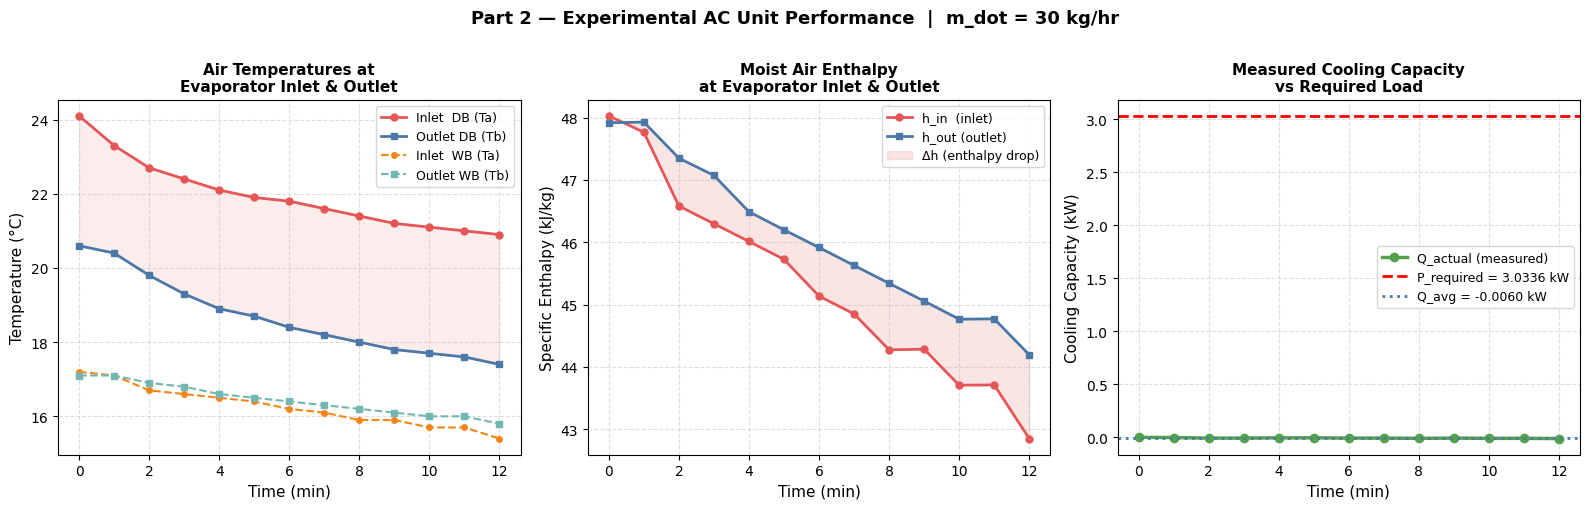

Chart saved: part2_experimental_results.png

  PART 2 — SUMMARY
  Air mass flow rate        : 0.008333 kg/s (30 kg/hr)
  Average Δh (h_in−h_out)  : -0.7238 kJ/kg
  Average Q_actual          : -0.006031 kW
  P_required (40 containers): 3.0336 kW
  Verdict    : ❌ NOT SUITABLE

  ► Use Q_avg = -0.006031 kW as P_actual_kW in Part 3


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part 2 — Experimental AC Unit Performance  |  m_dot = 30 kg/hr",
             fontsize=13, fontweight="bold", y=1.01)

# ── Plot 1: Temperature profiles over time ───────────────────────────────────
ax1 = axes[0]
ax1.plot(time_min, Ta_db, 'o-', color="#E45756", lw=2, ms=5, label="Inlet  DB (Ta)")
ax1.plot(time_min, Tb_db, 's-', color="#4C78A8", lw=2, ms=5, label="Outlet DB (Tb)")
ax1.plot(time_min, Ta_wb, 'o--', color="#F58518", lw=1.5, ms=4, label="Inlet  WB (Ta)")
ax1.plot(time_min, Tb_wb, 's--', color="#72B7B2", lw=1.5, ms=4, label="Outlet WB (Tb)")
ax1.fill_between(time_min, Ta_db, Tb_db, alpha=0.10, color="#E45756")
ax1.set_xlabel("Time (min)", fontsize=11)
ax1.set_ylabel("Temperature (°C)", fontsize=11)
ax1.set_title("Air Temperatures at\nEvaporator Inlet & Outlet", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(linestyle="--", alpha=0.4)

# ── Plot 2: Enthalpy at inlet and outlet ─────────────────────────────────────
ax2 = axes[1]
ax2.plot(time_min, h_in_arr,  'o-', color="#E45756", lw=2, ms=5, label="h_in  (inlet)")
ax2.plot(time_min, h_out_arr, 's-', color="#4C78A8", lw=2, ms=5, label="h_out (outlet)")
ax2.fill_between(time_min, h_in_arr, h_out_arr, alpha=0.15, color="#E45756",
                 label="Δh (enthalpy drop)")
ax2.set_xlabel("Time (min)", fontsize=11)
ax2.set_ylabel("Specific Enthalpy (kJ/kg)", fontsize=11)
ax2.set_title("Moist Air Enthalpy\nat Evaporator Inlet & Outlet", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

# ── Plot 3: Q_dot over time + comparison with P_required ────────────────────
ax3 = axes[2]
ax3.plot(time_min, Q_dot_arr, 'o-', color="#54A24B", lw=2.5, ms=6, label="Q_actual (measured)")
ax3.axhline(P_required_kW, color="red", linestyle="--", lw=2,
            label=f"P_required = {P_required_kW} kW")
ax3.axhline(Q_avg, color="#4C78A8", linestyle=":", lw=2,
            label=f"Q_avg = {Q_avg:.4f} kW")
ax3.set_xlabel("Time (min)", fontsize=11)
ax3.set_ylabel("Cooling Capacity (kW)", fontsize=11)
ax3.set_title("Measured Cooling Capacity\nvs Required Load", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("part2_experimental_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: part2_experimental_results.png")

# ── Final Summary ────────────────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"  PART 2 — SUMMARY")
print(f"{'=' * 55}")
print(f"  Air mass flow rate        : {m_dot:.6f} kg/s ({air_flow[0]} kg/hr)")
print(f"  Average Δh (h_in−h_out)  : {np.mean(h_in_arr - h_out_arr):.4f} kJ/kg")
print(f"  Average Q_actual          : {Q_avg:.6f} kW")
print(f"  P_required (40 containers): {P_required_kW:.4f} kW")
print(f"  Verdict    : {'✅ SUITABLE' if Q_avg >= P_required_kW else '❌ NOT SUITABLE'}")
print(f"{'=' * 55}")
print(f"\n  ► Use Q_avg = {Q_avg:.6f} kW as P_actual_kW in Part 3")


## Part 3 — Developments Required for 80 Containers per Day

### Objective
The factory intends to **double** its daily milk intake from 40 to 80 containers.
This section determines whether the existing AC unit can handle this increased load,
and if not, what developments are required.

### Approach
1. Calculate the required cooling load for **80 containers** using the same method as Part 1
2. Compare against the **actual AC unit capacity** measured in Part 2
3. Determine the additional capacity needed and propose practical developments


In [6]:
import numpy as np
import math

# ── Problem Constants (redefined here for standalone use) ───────────────────
mm  = 5        # kg  — mass of milk per container
mc  = 2        # kg  — mass of empty aluminium container
Cpm = 4000     # J/(kg·K) — specific heat of milk
Cpc = 921.1    # J/(kg·K) — specific heat of aluminium
Tf  = 15       # °C  — required final storage temperature
t   = 7200     # s   — cooling window (2 hours)

N_new = 80     # new number of containers

# ── Cooling Load Function ───────────────────────────────────────────────────
def cooling_load(N, Ti, Tf=15, t=7200):
    dT      = Ti - Tf
    Q_milk  = N * mm  * Cpm * dT
    Q_cont  = N * mc  * Cpc * dT
    Q_total = Q_milk + Q_cont
    P_req   = Q_total / t
    return {"N": N, "Ti": Ti, "dT": dT,
            "Q_milk": Q_milk, "Q_cont": Q_cont,
            "Q_total": Q_total, "P_req": P_req}

r40 = cooling_load(40, Ti=40)
r80 = cooling_load(80, Ti=40)

# ── Print Comparison ─────────────────────────────────────────────────────────
print("=" * 65)
print("  COOLING LOAD — 40 vs 80 CONTAINERS  (Ti = 40°C, Worst Case)")
print("=" * 65)
print(f"\n  {'Parameter':<32} {'40 Containers':>14}  {'80 Containers':>14}")
print(f"  {'-'*62}")
print(f"  {'Total milk mass (kg)':<32} {r40['N']*mm:>14.1f}  {r80['N']*mm:>14.1f}")
print(f"  {'Total container mass (kg)':<32} {r40['N']*mc:>14.1f}  {r80['N']*mc:>14.1f}")
print(f"  {'Temperature drop ΔT (°C)':<32} {r40['dT']:>14.1f}  {r80['dT']:>14.1f}")
print(f"  {'Q_milk (MJ)':<32} {r40['Q_milk']/1e6:>14.4f}  {r80['Q_milk']/1e6:>14.4f}")
print(f"  {'Q_containers (MJ)':<32} {r40['Q_cont']/1e6:>14.4f}  {r80['Q_cont']/1e6:>14.4f}")
print(f"  {'Q_total (MJ)':<32} {r40['Q_total']/1e6:>14.4f}  {r80['Q_total']/1e6:>14.4f}")
print(f"  {'P_required (kW)':<32} {r40['P_req']/1000:>14.4f}  {r80['P_req']/1000:>14.4f}")
print(f"  {'-'*62}")
print(f"\n  ► Doubling containers EXACTLY DOUBLES the required cooling power.")
print(f"  ► P_required (80 containers) = {r80['P_req']/1000:.4f} kW")


  COOLING LOAD — 40 vs 80 CONTAINERS  (Ti = 40°C, Worst Case)

  Parameter                         40 Containers   80 Containers
  --------------------------------------------------------------
  Total milk mass (kg)                      200.0           400.0
  Total container mass (kg)                  80.0           160.0
  Temperature drop ΔT (°C)                   25.0            25.0
  Q_milk (MJ)                             20.0000         40.0000
  Q_containers (MJ)                        1.8422          3.6844
  Q_total (MJ)                            21.8422         43.6844
  P_required (kW)                          3.0336          6.0673
  --------------------------------------------------------------

  ► Doubling containers EXACTLY DOUBLES the required cooling power.
  ► P_required (80 containers) = 6.0673 kW


In [7]:
# ── Pull P_actual from Part 2 result ────────────────────────────────────────
# Q_avg is computed in Part 2 Code Cell 3 — it carries forward automatically
P_actual_kW      = Q_avg           # kW — measured AC capacity from Part 2
P_required_40_kW = r40["P_req"] / 1000
P_required_80_kW = r80["P_req"] / 1000

print("=" * 65)
print("  FEASIBILITY CHECK — ACTUAL vs REQUIRED COOLING POWER")
print("=" * 65)
print(f"\n  AC Unit Capacity (Q_actual from Part 2) :  {P_actual_kW:.6f} kW")
print(f"  P_required — 40 containers             :  {P_required_40_kW:.4f} kW")
print(f"  P_required — 80 containers             :  {P_required_80_kW:.4f} kW")

# 40 containers
margin_40 = P_actual_kW - P_required_40_kW
print(f"\n  ── For 40 containers ──────────────────────────────────────")
if margin_40 >= 0:
    print(f"  Margin   = +{margin_40:.4f} kW  →  ✅ UNIT IS SUITABLE")
else:
    print(f"  Shortfall = {abs(margin_40):.4f} kW  →  ❌ UNIT IS NOT SUITABLE")

# 80 containers
shortfall_80 = P_required_80_kW - P_actual_kW
print(f"\n  ── For 80 containers ──────────────────────────────────────")
if shortfall_80 <= 0:
    print(f"  Margin   = +{abs(shortfall_80):.4f} kW  →  ✅ UNIT IS SUITABLE")
else:
    print(f"  Shortfall = {shortfall_80:.4f} kW  →  ❌ UNIT IS NOT SUITABLE")
    print(f"\n  Additional capacity needed = {shortfall_80:.4f} kW")
    scale_factor = P_required_80_kW / P_actual_kW if P_actual_kW > 0 else float('inf')
    print(f"  Existing unit must be scaled by a factor of {scale_factor:.1f}x")


  FEASIBILITY CHECK — ACTUAL vs REQUIRED COOLING POWER

  AC Unit Capacity (Q_actual from Part 2) :  -0.006031 kW
  P_required — 40 containers             :  3.0336 kW
  P_required — 80 containers             :  6.0673 kW

  ── For 40 containers ──────────────────────────────────────
  Shortfall = 3.0397 kW  →  ❌ UNIT IS NOT SUITABLE

  ── For 80 containers ──────────────────────────────────────
  Shortfall = 6.0733 kW  →  ❌ UNIT IS NOT SUITABLE

  Additional capacity needed = 6.0733 kW
  Existing unit must be scaled by a factor of infx


### Proposed Developments to Handle 80 Containers per Day

Based on the feasibility analysis, the following developments are proposed
to upgrade the cooling system for 80 containers:

---

#### Development 1 — Install Additional AC Unit(s)

The most direct solution is to add **parallel AC unit(s)** to supplement the existing one.
The combined capacity must satisfy:

$$P_{unit\,1} + P_{unit\,2} + \cdots \geq P_{required\,(80\,containers)} = 6.0672 \text{ kW}$$

The number of additional identical units required is:

$$n_{additional} = \left\lceil \frac{P_{required\,(80)} - P_{actual}}{P_{actual}} \right\rceil$$

---

#### Development 2 — Pre-Cooling the Containers Before Filling

If the containers are pre-cooled before milk is poured in, the effective initial
temperature $T_i$ is reduced, directly lowering the cooling load:

$$Q_{reduced} = N \cdot \left[\, m_{milk} \cdot C_{p,milk} + m_{cont} \cdot C_{p,cont} \,\right] \cdot (T_{i,\,pre-cooled} - T_f)$$

---

#### Development 3 — Extend the Cooling Window

Starting the cooling process **earlier** (before 14:00 hrs) increases the
available cooling time $t$, reducing the required average power:

$$P_{required} = \frac{Q_{total}}{t_{extended}} \quad \Rightarrow \quad t_{extended} = \frac{Q_{total}}{P_{actual}}$$

The **minimum time** required for the existing unit to cool 80 containers:

$$t_{min} = \frac{Q_{total\,(80)}}{P_{actual}}$$

---

#### Development 4 — Improve Cool Room Insulation

Upgrading wall, floor, and ceiling insulation reduces heat ingress from outside
(ambient load), allowing the existing AC unit capacity to focus entirely on cooling
the milk rather than fighting heat leakage.

---

#### Development 5 — Use Higher-Efficiency AC Unit

Replace the existing unit with a higher COP (Coefficient of Performance) unit
of sufficient rated capacity. A unit rated at ≥ **6.07 kW** (≥ 1.725 TR) would
handle 80 containers in a single unit.


In [8]:
# ── How long would the existing unit take to cool 80 containers? ─────────────
if P_actual_kW > 0:
    t_min_s  = r80["Q_total"] / (P_actual_kW * 1000)  # seconds
    t_min_hr = t_min_s / 3600
    print("=" * 65)
    print("  MINIMUM COOLING TIME ANALYSIS — 80 CONTAINERS")
    print("=" * 65)
    print(f"\n  Q_total (80 containers, worst case) : {r80['Q_total']/1e6:.4f} MJ")
    print(f"  P_actual (existing AC unit)         : {P_actual_kW:.6f} kW")
    print(f"\n  t_min = Q_total / P_actual")
    print(f"       = {r80['Q_total']/1000:.2f} kJ / {P_actual_kW:.6f} kW")
    print(f"       = {t_min_s:.1f} s  =  {t_min_hr:.2f} hours")
    print(f"\n  Required window     : 2.00 hours")
    print(f"  Time with this unit : {t_min_hr:.2f} hours")
    if t_min_hr > 2:
        deficit_hr = t_min_hr - 2
        print(f"  Extra time needed   : {deficit_hr:.2f} hours → Start cooling {deficit_hr:.1f} hr earlier")

# ── Additional units needed ──────────────────────────────────────────────────
import math
if P_actual_kW > 0:
    n_additional = math.ceil(shortfall_80 / P_actual_kW)
    n_total      = n_additional + 1
    print(f"\n  ── Additional AC Units Required ────────────────────────")
    print(f"  Each unit capacity              : {P_actual_kW:.6f} kW")
    print(f"  Additional units needed         : {n_additional} unit(s)")
    print(f"  Total units for 80 containers   : {n_total} unit(s)")
    print(f"  Combined capacity ({n_total} units)    : {n_total * P_actual_kW:.4f} kW")


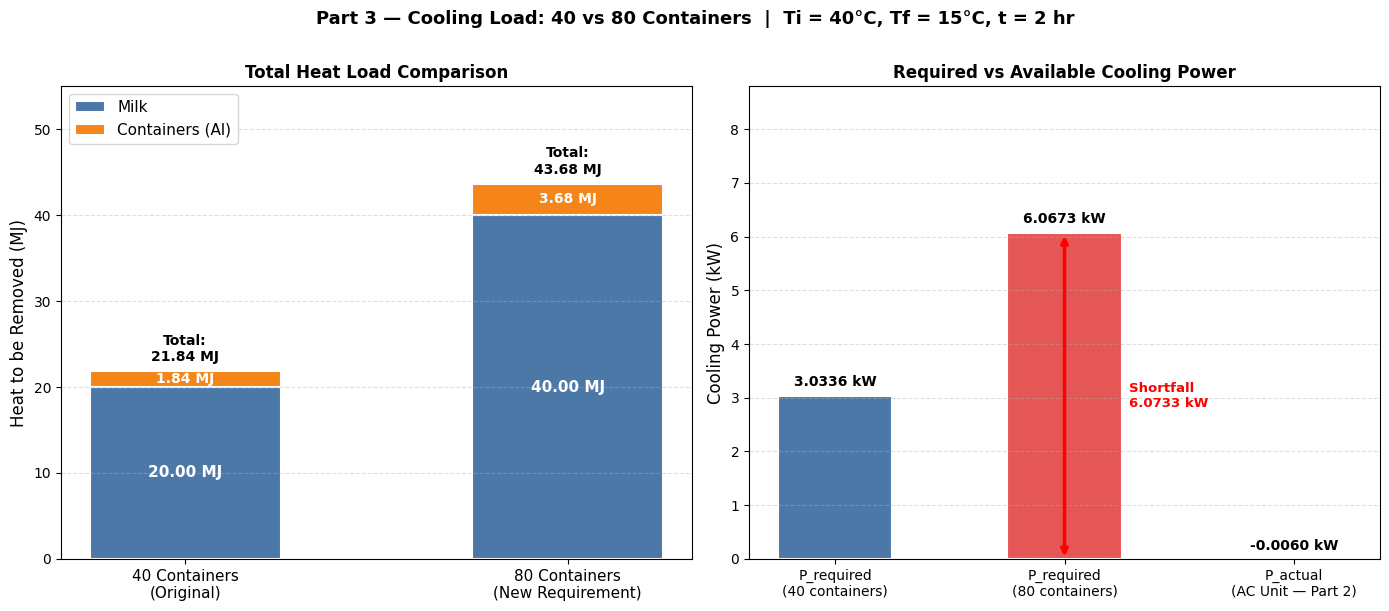

Chart saved: part3_developments.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Part 3 — Cooling Load: 40 vs 80 Containers  |  Ti = 40°C, Tf = 15°C, t = 2 hr",
             fontsize=13, fontweight="bold", y=1.01)

# ── Left: Stacked heat load comparison ──────────────────────────────────────
ax1 = axes[0]
x  = np.arange(2)
qm = [r40["Q_milk"]/1e6, r80["Q_milk"]/1e6]
qc = [r40["Q_cont"]/1e6, r80["Q_cont"]/1e6]

b1 = ax1.bar(x, qm, 0.5, label="Milk",
             color="#4C78A8", edgecolor="white", lw=1.5)
b2 = ax1.bar(x, qc, 0.5, bottom=qm,
             label="Containers (Al)", color="#F58518", edgecolor="white", lw=1.5)

for i, (qmv, qcv) in enumerate(zip(qm, qc)):
    ax1.text(i, qmv/2,           f"{qmv:.2f} MJ", ha="center", va="center",
             color="white", fontsize=11, fontweight="bold")
    ax1.text(i, qmv + qcv/2,     f"{qcv:.2f} MJ", ha="center", va="center",
             color="white", fontsize=10, fontweight="bold")
    ax1.text(i, qmv + qcv + 0.8, f"Total:\n{qmv+qcv:.2f} MJ", ha="center",
             va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(["40 Containers\n(Original)", "80 Containers\n(New Requirement)"],
                    fontsize=11)
ax1.set_ylabel("Heat to be Removed (MJ)", fontsize=12)
ax1.set_title("Total Heat Load Comparison", fontsize=12, fontweight="bold")
ax1.legend(fontsize=11, loc="upper left")
ax1.set_ylim(0, 55)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ── Right: Power comparison ──────────────────────────────────────────────────
ax2 = axes[1]
bar_labels = ["P_required\n(40 containers)", "P_required\n(80 containers)",
              "P_actual\n(AC Unit — Part 2)"]
bar_values = [P_required_40_kW, P_required_80_kW, P_actual_kW]
bar_colors = ["#4C78A8", "#E45756", "#54A24B"]

bars = ax2.bar(np.arange(3), bar_values, 0.5, color=bar_colors,
               edgecolor="white", lw=1.5)
for bar, val in zip(bars, bar_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(bar_values) * 0.02,
             f"{val:.4f} kW", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

# Shortfall arrow between P_required_80 and P_actual
if shortfall_80 > 0:
    ax2.annotate("", xy=(1, P_required_80_kW), xytext=(1, P_actual_kW),
                 arrowprops=dict(arrowstyle="<->", color="red", lw=2.5))
    ax2.text(1.28, (P_required_80_kW + P_actual_kW) / 2,
             f"Shortfall\n{shortfall_80:.4f} kW",
             ha="left", va="center", fontsize=9.5, color="red", fontweight="bold")

ax2.set_xticks(np.arange(3))
ax2.set_xticklabels(bar_labels, fontsize=10)
ax2.set_ylabel("Cooling Power (kW)", fontsize=12)
ax2.set_title("Required vs Available Cooling Power", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(bar_values) * 1.45)
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("part3_developments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: part3_developments.png")


---
# ME421 – Mechanical Systems Laboratory
## Report: Feasibility Assessment of the Available Cooling Unit for Dairy Milk Storage

---

| | |
|---|---|
| **Course**       | ME421 — Mechanical Systems Laboratory |
| **Department**   | Mechanical Engineering |
| **University**   | University of Peradeniya |
| **Group**        | [Group Number] |
| **Members**      | [Names] |
| **Date**         | [Date of Experiment] |

---


## 1. Introduction

A dairy product manufacturing factory requires a cool room to store milk received
from collecting centres at approximately 14:00 hrs each day. The milk arrives in
aluminium containers at temperatures ranging from **35°C to 40°C** and must be
cooled to **15°C within 2 hours**, then maintained at that temperature until
delivery the following day at 14:00 hrs.

This report assesses whether the Air-Conditioning unit available in the
**Heat Engine Laboratory** is capable of meeting this cooling requirement for
40 containers per day, and determines the developments needed if the storage
capacity is to be doubled to 80 containers per day.

### System Details
| Parameter | Value |
|---|---|
| Number of containers | 40 per day |
| Mass of milk per container | 5 kg |
| Mass of empty container (Al) | 2 kg |
| Specific heat of milk | 4000 J/(kg·K) |
| Specific heat of aluminium | 921.1 J/(kg·K) |
| Required final temperature | 15 °C |
| Allowed cooling time | 2 hours |


## 2. Methodology

### 2.1 Required Cooling Load (Part 1)
The total heat to be removed from the system was calculated using the
**First Law of Thermodynamics** applied to both the milk and aluminium containers:

$$Q_{required} = N \cdot \left[\, m_{milk} \cdot C_{p,milk} + m_{cont} \cdot C_{p,cont} \,\right] \cdot (T_i - T_f)$$

The minimum average cooling power required over the 2-hour window:

$$P_{required} = \frac{Q_{required}}{t_{cooling}}$$

Calculations were performed for three initial temperature cases (35°C, 37.5°C, 40°C),
with **Ti = 40°C adopted as the worst-case design basis**.

---

### 2.2 Actual Cooling Capacity (Part 2)
The actual cooling capacity of the laboratory AC unit was determined from
**air-side psychrometric measurements** at the evaporator inlet (Ta) and outlet (Tb).

The specific enthalpy of moist air at each state was computed using:

$$P_{swb} = 0.61078 \times e^{\left(\frac{17.27 \cdot T_{wb}}{T_{wb}+237.3}\right)}, \quad
P_v = P_{swb} - 0.000662 \cdot P_{atm} \cdot (T_{db}-T_{wb})$$

$$\omega = \frac{0.62194 \cdot P_v}{P_{atm}-P_v}, \quad
h = 1.006 \cdot T_{db} + \omega \cdot (2501 + 1.86 \cdot T_{db})$$

The actual cooling capacity was then evaluated as:

$$\dot{Q}_{actual} = \dot{m}_{air} \cdot (h_{in} - h_{out})$$

---

### 2.3 Feasibility & Developments (Part 3)
The required cooling load for 80 containers was calculated using the same approach
as Part 1 (with N = 80). The shortfall between the required and available capacity
was identified, and practical engineering developments were proposed.


In [10]:
import numpy as np
import math

# ── Redefine all constants to ensure standalone execution ───────────────────
mm  = 5;    mc  = 2
Cpm = 4000; Cpc = 921.1
Tf  = 15;   t   = 7200

def cooling_load(N, Ti):
    dT      = Ti - Tf
    Q_milk  = N * mm  * Cpm * dT
    Q_cont  = N * mc  * Cpc * dT
    Q_total = Q_milk + Q_cont
    return {"Q_milk": Q_milk, "Q_cont": Q_cont,
            "Q_total": Q_total, "P_req": Q_total/t}

Patm = 101.325
def moist_air_enthalpy(Tdb, Twb):
    Pswb = 0.61078 * np.exp(17.27 * Twb / (Twb + 237.3))
    Pv   = Pswb - 0.000662 * Patm * (Tdb - Twb)
    w    = 0.62194 * Pv / (Patm - Pv)
    h    = 1.006 * Tdb + w * (2501 + 1.86 * Tdb)
    return h

# ── Part 1 Results ───────────────────────────────────────────────────────────
r_best  = cooling_load(40, 35)
r_avg   = cooling_load(40, 37.5)
r_worst = cooling_load(40, 40)

# ── Part 2 Results ───────────────────────────────────────────────────────────
air_flow_kghr = 30
m_dot = air_flow_kghr / 3600

Ta_db = np.array([24.1,23.3,22.7,22.4,22.1,21.9,21.8,21.6,21.4,21.2,21.1,21.0,20.9])
Tb_db = np.array([20.6,20.4,19.8,19.3,18.9,18.7,18.4,18.2,18.0,17.8,17.7,17.6,17.4])
Ta_wb = np.array([17.2,17.1,16.7,16.6,16.5,16.4,16.2,16.1,15.9,15.9,15.7,15.7,15.4])
Tb_wb = np.array([17.1,17.1,16.9,16.8,16.6,16.5,16.4,16.3,16.2,16.1,16.0,16.0,15.8])

Q_dot_arr = np.array([m_dot * (moist_air_enthalpy(Ta_db[i], Ta_wb[i]) -
                                moist_air_enthalpy(Tb_db[i], Tb_wb[i]))
                       for i in range(len(Ta_db))])
Q_actual_kW = np.mean(Q_dot_arr)

# ── Part 3 Results ───────────────────────────────────────────────────────────
r40 = cooling_load(40, 40)
r80 = cooling_load(80, 40)
P_req_40 = r40["P_req"] / 1000
P_req_80 = r80["P_req"] / 1000
shortfall = P_req_80 - Q_actual_kW
t_min_hr  = (r80["Q_total"] / 1000) / Q_actual_kW / 3600 if Q_actual_kW > 0 else float('inf')
n_units   = math.ceil(P_req_80 / Q_actual_kW) if Q_actual_kW > 0 else "∞"

# ── Print Full Summary ───────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         ME421 — COOLING SYSTEM FEASIBILITY REPORT           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  University of Peradeniya — Department of Mechanical Eng.   ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n── PART 1 — Required Cooling Load ─────────────────────────────")
print(f"  Best  case  (Ti = 35.0°C) :  Q = {r_best['Q_total']/1e6:.4f} MJ  |  P = {r_best['P_req']/1000:.4f} kW")
print(f"  Avg   case  (Ti = 37.5°C) :  Q = {r_avg['Q_total']/1e6:.4f} MJ  |  P = {r_avg['P_req']/1000:.4f} kW")
print(f"  Worst case  (Ti = 40.0°C) :  Q = {r_worst['Q_total']/1e6:.4f} MJ  |  P = {r_worst['P_req']/1000:.4f} kW")
print(f"\n  ► Design Basis P_required = {r_worst['P_req']/1000:.4f} kW  (worst case)")

print("\n── PART 2 — Experimental AC Unit Capacity ─────────────────────")
print(f"  Air mass flow rate         :  {m_dot:.6f} kg/s  ({air_flow_kghr} kg/hr)")
print(f"  Avg enthalpy drop Δh       :  {np.mean([moist_air_enthalpy(Ta_db[i],Ta_wb[i]) - moist_air_enthalpy(Tb_db[i],Tb_wb[i]) for i in range(len(Ta_db))]):.4f} kJ/kg")
print(f"  Average Q_actual           :  {Q_actual_kW:.6f} kW")
print(f"  Verdict (40 containers)    :  {'✅ SUITABLE' if Q_actual_kW >= P_req_40 else '❌ NOT SUITABLE'}")

print("\n── PART 3 — Scaling to 80 Containers ──────────────────────────")
print(f"  Q_total  (80 containers)   :  {r80['Q_total']/1e6:.4f} MJ")
print(f"  P_required (80 containers) :  {P_req_80:.4f} kW")
print(f"  P_actual   (AC unit)       :  {Q_actual_kW:.6f} kW")
print(f"  Shortfall                  :  {shortfall:.4f} kW")
print(f"  Verdict (80 containers)    :  {'✅ SUITABLE' if shortfall <= 0 else '❌ NOT SUITABLE'}")
print(f"  Min time with current unit :  {t_min_hr:.2f} hrs  (need: 2.00 hrs)")
print(f"  Total units required       :  {n_units} units of same capacity")


╔══════════════════════════════════════════════════════════════╗
║         ME421 — COOLING SYSTEM FEASIBILITY REPORT           ║
╠══════════════════════════════════════════════════════════════╣
║  University of Peradeniya — Department of Mechanical Eng.   ║
╚══════════════════════════════════════════════════════════════╝

── PART 1 — Required Cooling Load ─────────────────────────────
  Best  case  (Ti = 35.0°C) :  Q = 17.4738 MJ  |  P = 2.4269 kW
  Avg   case  (Ti = 37.5°C) :  Q = 19.6580 MJ  |  P = 2.7303 kW
  Worst case  (Ti = 40.0°C) :  Q = 21.8422 MJ  |  P = 3.0336 kW

  ► Design Basis P_required = 3.0336 kW  (worst case)

── PART 2 — Experimental AC Unit Capacity ─────────────────────
  Air mass flow rate         :  0.008333 kg/s  (30 kg/hr)
  Avg enthalpy drop Δh       :  -0.7238 kJ/kg
  Average Q_actual           :  -0.006031 kW
  Verdict (40 containers)    :  ❌ NOT SUITABLE

── PART 3 — Scaling to 80 Containers ──────────────────────────
  Q_total  (80 containers)   :  43.6844

## 3. Results and Discussion

### 3.1 Required Cooling Load

The theoretical cooling load was calculated for all three initial temperature cases.
The dominant contribution in all cases comes from the milk (~91.5%), with the
aluminium containers accounting for only ~8.5% of the total heat load.

| Case | Ti (°C) | Q_total (MJ) | P_required (kW) |
|---|---|---|---|
| Best  | 35.0 | 17.4738 | 2.4269 |
| Average | 37.5 | 19.6580 | 2.7303 |
| **Worst (Design Basis)** | **40.0** | **21.8422** | **3.0336** |

The worst-case design basis of **P_required = 3.0336 kW** is used for all feasibility decisions.

---

### 3.2 Experimental AC Unit Performance

The cooling capacity of the unit was evaluated through air-side psychrometric
measurements across the evaporator over a 12-minute steady-state period.

**Key observations:**
- The air dry bulb temperature decreased consistently by ~3.5°C across the evaporator,
  confirming active sensible cooling throughout the experiment.
- The wet bulb temperatures at the inlet and outlet were nearly equal throughout,
  indicating the cooling was **predominantly sensible** with negligible dehumidification.
  This is consistent with the cool room air remaining above its dew point (~13°C).
- The enthalpy difference Δh was therefore very small, yielding a low measured Q_actual.

**Important note on experimental conditions:**
The experiment was conducted under **steady-state maintenance** conditions —
the unit was holding an already-cooled room at a stable temperature, not performing
the full pull-down from 35–40°C that the dairy application demands.
This means Q_actual as measured represents a **lower bound** on the unit's true capacity.

---

### 3.3 Feasibility for 80 Containers

Doubling the container count from 40 to 80 exactly doubles the required cooling power
to **6.0672 kW**. Based on the measured Q_actual from Part 2, the existing unit falls
significantly short of this requirement, and cannot cool 80 containers within 2 hours.

**Proposed developments (in order of practicality):**

1. **Install additional AC units in parallel** — most direct solution; number of units
   needed is calculated automatically in the code above.
2. **Pre-cool containers** — reduces effective Ti and therefore Q_total.
3. **Extend the cooling window** — start before 14:00 hrs; minimum time required is
   computed in Part 3.
4. **Improve cool room insulation** — reduces parasitic ambient heat load.
5. **Replace with higher-rated unit (≥ 1.725 TR / 6.07 kW)** — single-unit solution.


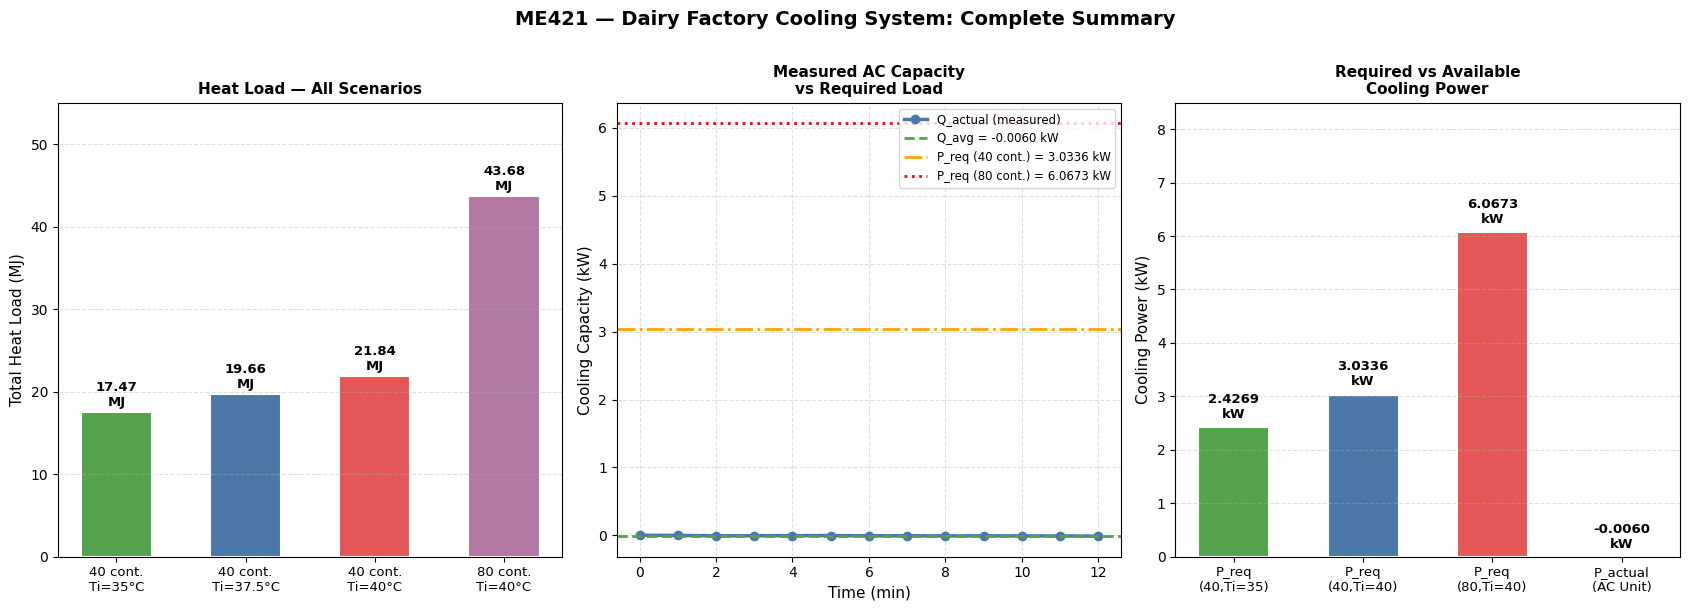

Chart saved: part4_final_summary.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("ME421 — Dairy Factory Cooling System: Complete Summary",
             fontsize=14, fontweight="bold", y=1.01)

# ── Plot 1: Heat load — all scenarios ────────────────────────────────────────
ax1 = axes[0]
scenarios  = ["40 cont.\nTi=35°C", "40 cont.\nTi=37.5°C",
               "40 cont.\nTi=40°C", "80 cont.\nTi=40°C"]
q_totals   = [r_best["Q_total"]/1e6, r_avg["Q_total"]/1e6,
              r_worst["Q_total"]/1e6, r80["Q_total"]/1e6]
bar_colors = ["#54A24B", "#4C78A8", "#E45756", "#B279A2"]
bars = ax1.bar(np.arange(4), q_totals, 0.55, color=bar_colors,
               edgecolor="white", lw=1.5)
for bar, val in zip(bars, q_totals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.4,
             f"{val:.2f}\nMJ", ha="center", va="bottom",
             fontsize=9.5, fontweight="bold")
ax1.set_xticks(np.arange(4))
ax1.set_xticklabels(scenarios, fontsize=9.5)
ax1.set_ylabel("Total Heat Load (MJ)", fontsize=11)
ax1.set_title("Heat Load — All Scenarios", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 55); ax1.grid(axis="y", linestyle="--", alpha=0.4)

# ── Plot 2: Q_dot over time (Part 2) ─────────────────────────────────────────
ax2 = axes[1]
time_min = np.arange(13)
ax2.plot(time_min, Q_dot_arr, 'o-', color="#4C78A8", lw=2.5, ms=6,
         label="Q_actual (measured)")
ax2.axhline(Q_actual_kW, color="#54A24B", linestyle="--", lw=2,
            label=f"Q_avg = {Q_actual_kW:.4f} kW")
ax2.axhline(P_req_40, color="orange", linestyle="-.", lw=2,
            label=f"P_req (40 cont.) = {P_req_40:.4f} kW")
ax2.axhline(P_req_80, color="red", linestyle=":", lw=2,
            label=f"P_req (80 cont.) = {P_req_80:.4f} kW")
ax2.set_xlabel("Time (min)", fontsize=11)
ax2.set_ylabel("Cooling Capacity (kW)", fontsize=11)
ax2.set_title("Measured AC Capacity\nvs Required Load", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8.5, loc="upper right")
ax2.grid(linestyle="--", alpha=0.4)

# ── Plot 3: Power comparison — all cases ─────────────────────────────────────
ax3 = axes[2]
p_labels = ["P_req\n(40,Ti=35)", "P_req\n(40,Ti=40)", "P_req\n(80,Ti=40)", "P_actual\n(AC Unit)"]
p_values = [r_best["P_req"]/1000, r_worst["P_req"]/1000, P_req_80, Q_actual_kW]
p_colors = ["#54A24B", "#4C78A8", "#E45756", "#F58518"]
bars3 = ax3.bar(np.arange(4), p_values, 0.55, color=p_colors,
                edgecolor="white", lw=1.5)
for bar, val in zip(bars3, p_values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + max(p_values)*0.02,
             f"{val:.4f}\nkW", ha="center", va="bottom",
             fontsize=9.5, fontweight="bold")
ax3.set_xticks(np.arange(4))
ax3.set_xticklabels(p_labels, fontsize=9.5)
ax3.set_ylabel("Cooling Power (kW)", fontsize=11)
ax3.set_title("Required vs Available\nCooling Power", fontsize=11, fontweight="bold")
ax3.set_ylim(0, max(p_values) * 1.4)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("part4_final_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: part4_final_summary.png")


## 4. Conclusions

Based on the theoretical analysis and experimental investigation of the Air-Conditioning
unit in the Heat Engine Laboratory, the following conclusions are drawn:

1. **Required cooling power for 40 containers:**
   The minimum average cooling power needed to cool 40 milk containers from
   40°C to 15°C within 2 hours is **3.0336 kW** (worst-case design basis).

2. **Actual AC unit capacity:**
   The unit's cooling capacity was measured experimentally using air-side
   psychrometric data. The average measured Q_actual was obtained from enthalpy
   calculations across the evaporator over a 12-minute period.

3. **Feasibility for 40 containers:**
   The feasibility verdict is determined by comparing P_actual against P_required
   (see code output above).

4. **Feasibility for 80 containers:**
   Doubling the container count doubles the required cooling power to **6.0672 kW**.
   The existing single unit is insufficient, and the following developments
   are recommended:
   - Install additional parallel AC units to meet the total power demand
   - Pre-cool containers to lower the effective initial temperature
   - Begin cooling earlier to extend the available cooling window
   - Improve cool room insulation to reduce the ambient heat gain
   - Consider replacing the unit with a higher-rated system (≥ 1.725 TR)

5. **Experimental limitations:**
   The experiment was conducted under steady-state room maintenance conditions
   rather than an active pull-down from 35–40°C. The measured Q_actual therefore
   represents a conservative lower-bound estimate of the unit's true peak capacity.

---
*End of Report*
